## Basics

In [1]:
#import relevant libraries
import os
from scipy import stats
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime


date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap
import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import osar 

#NOTE: SUPPRESSES WARNINGS!

import warnings
warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

print(osar.__version__)

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 21.09it/s]


Numba compilation complete!
0.23.9


In [2]:
officecomp = "C:\\Users\\Star\\"
labcomp = "C:\\Users\\User\\"
computer2 = "C:\\Users\\lnico\\"
homecomp = "D:\\"
specifiedpath = homecomp
filedate = "20251023"

filedirectory_OSAR = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\2025collection\\"
filedirectory_Falling = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025deltagcollection\\"
filesavedir = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Totalosarfalling\\images\\"

In [3]:
#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

## Function

In [6]:
def find_number(df, lookup_value, genre):
    lobe_values = []
    for _, row in df.iterrows():
        # Splitting the 'MBON' values and removing any potential whitespace
        mbon_values = [x.strip() for x in row['MBON names'].split(',')]
        if lookup_value in mbon_values:
            lobe_values.append(row[genre])
            
    lobelobe = list(set(lobe_values))
    return ', '.join(lobelobe)

def MBONnamefile(MBONList, pathfile):
    #reading mbonlist file

    #MBONFILEDIRECTORY: specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\"
    directorynew = os.path.dirname(os.path.dirname(pathfile)) #goes up one directory
    fileinnewdirc = os.listdir(directorynew)

    for file_no2 in fileinnewdirc:
        if ".csv" in file_no2:
            ff = os.path.join(directorynew, file_no2)
            csvfile = pd.read_csv(ff)

    csvfile = csvfile.astype('string')

    for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
        csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

    lobelocation = pd.DataFrame()

    for m in MBONList:
        lobeloc = pd.DataFrame()
        lobeloc['MBON'] = [m]
        loclst = find_number(csvfile, m, "Lobe")
        mbonlst = find_number(csvfile, m, "MBON number").strip()
        ntlst = find_number(csvfile, m, "Neurotransmitter")
        lobeloc['Lobe_location'] = [loclst]
        lobeloc['MBON number'] = [mbonlst]
        lobeloc['Neurotransmitter'] = [ntlst]
        
        lobelocation = pd.concat([lobelocation, lobeloc])

    lobelocation = lobelocation.reset_index(drop=True)
    return lobelocation

def matchingdfs (df, matchingset):
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = df[(df['MBON'] == n)]
        newdf_a = pd.concat([newdf_a, df_a]).reset_index(drop=True)
    return newdf_a

import textwrap

def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)
    
def matchinglobesets(dfreg_a, lobelocation):
    lobelocation_a = lobelocation.sort_values(by=['MBON']).reset_index(drop=True)
    dfreg_a_withloc = dfreg_a.sort_values(by=['MBON']).reset_index(drop=True)
    matchinglobereg = list(set(lobelocation_a['MBON']) & set(dfreg_a_withloc['MBON']))

    dflobe_reg = matchingdfs(lobelocation_a, matchinglobereg).sort_values(by=['MBON']).reset_index(drop=True)

    dfreg_a_withloc['Lobe_location'] = dflobe_reg['Lobe_location']
    dfreg_a_withloc['MBON number'] = dflobe_reg['MBON number']
    dfreg_a_withloc['Neurotransmitter'] = dflobe_reg['Neurotransmitter']

    return dfreg_a_withloc


def matchingcomp(dfreg_Cr2, osar_multiplot_cr2):
    matchingset = list(set(dfreg_Cr2['MBON']) & set(osar_multiplot_cr2['MBON']))
    newdf_a = pd.DataFrame()
    for n in matchingset:
        df_a=pd.DataFrame()
        df_a = dfreg_Cr2[(dfreg_Cr2['MBON'] == n)]
        df_b = pd.merge(df_a, osar_multiplot_cr2, on = "MBON" )
        newdf_a = pd.concat([newdf_a, df_b]).reset_index(drop=True)
    return newdf_a
        
def omission(df):
    tempdff = df[df['MBON'] != 'VT999036'].reset_index(drop=True) #removing outlier
    #dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) & (tempdff['Log2 Bout Speed ratio_Δg_OSAR'].abs() < 0.2))]
    dfomitted = tempdff[~((tempdff['PI_Δg_OSAR'].abs() < 0.2) )]
   
    return dfomitted.reset_index(drop=True)

## Formulas to run


In [5]:
fallingexcel = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Falling.xlsx")
MBONList = list(fallingexcel['MBON'].unique())

lobelocation = MBONnamefile(MBONList, specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\")

## Lin reg of OSAR

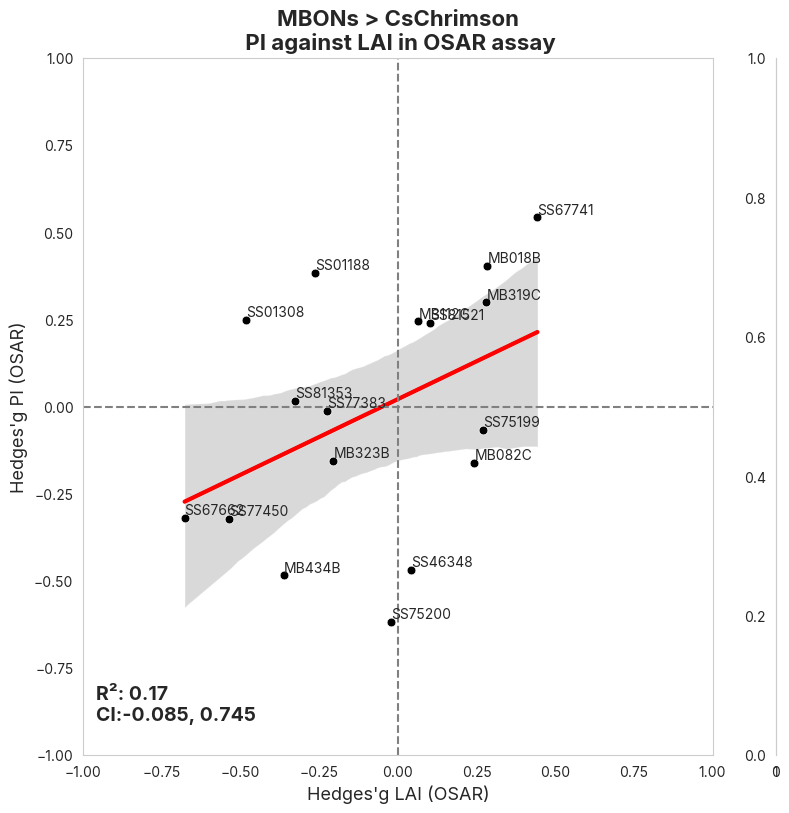

In [ ]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = 'Chrimson2'
   
# Read the specific condition file
totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-Full.xlsx")

if  responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colorline = "#ff0000"

if responder == 'ACR':
    responderrename = "GtACR1"
    df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colorline = "#14962c"

figosarplot, axscatter_o = plt.subplots(1, 2, figsize=(8, 8), gridspec_kw={"width_ratios":[1,0]})

# First subplot
y_label_1 = 'PI_Hg_OSAR'
x_label_1 = 'Light Attraction Index_Δg_OSAR'

df02omitteddf = df_specificmbon[~((df_specificmbon[x_label_1].abs() < 0.2) & (df_specificmbon[y_label_1].abs() < 0.2))].reset_index(drop=True)
df02omitteddf = df02omitteddf[~df02omitteddf['MBON'].isin(['VT999036'])]

sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[0]) #ci color
sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[0])  #line color
sns.scatterplot(x=x_label_1, y=y_label_1, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[0])

axscatter_o[0].set_ylabel("Hedges'g PI (OSAR)", fontsize = 13)
axscatter_o[0].set_xlabel("Hedges'g LAI (OSAR)", fontsize = 13)
axscatter_o[0].grid(False)
axscatter_o[0].set_ylim([-1, 1])
axscatter_o[0].set_xlim([-1, 1])
axscatter_o[0].axvline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[0].axhline(0, c=(.5, .5, .5), ls= '--')
axscatter_o[0].set_title("MBONs > " + responderrename + "\n PI against LAI in OSAR assay", weight = "bold", fontfamily = "Inter", fontsize = 16)
axscatter_o[0].yaxis.set_tick_params(labelbottom=True)

for n, k in enumerate(df02omitteddf['MBON']):
    axscatter_o[0].annotate(k, (df02omitteddf.loc[n,x_label_1], df02omitteddf.loc[n,y_label_1]+0.01), fontsize = 10)

#correlation for first subplot
pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(df02omitteddf[x_label_1], df02omitteddf[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
axscatter_o[0].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                        ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)

plt.tight_layout()
plt.subplots_adjust(top = 0.95, wspace=0.2)

# plt.savefig(filesavedir + date + "_" + responder + "_linreg_in OSAR only.png", dpi = 1200, bbox_inches='tight')
plt.savefig(filesavedir + date + "_" + responder + "_SPeedcomparisons_in OSAR only.svg")

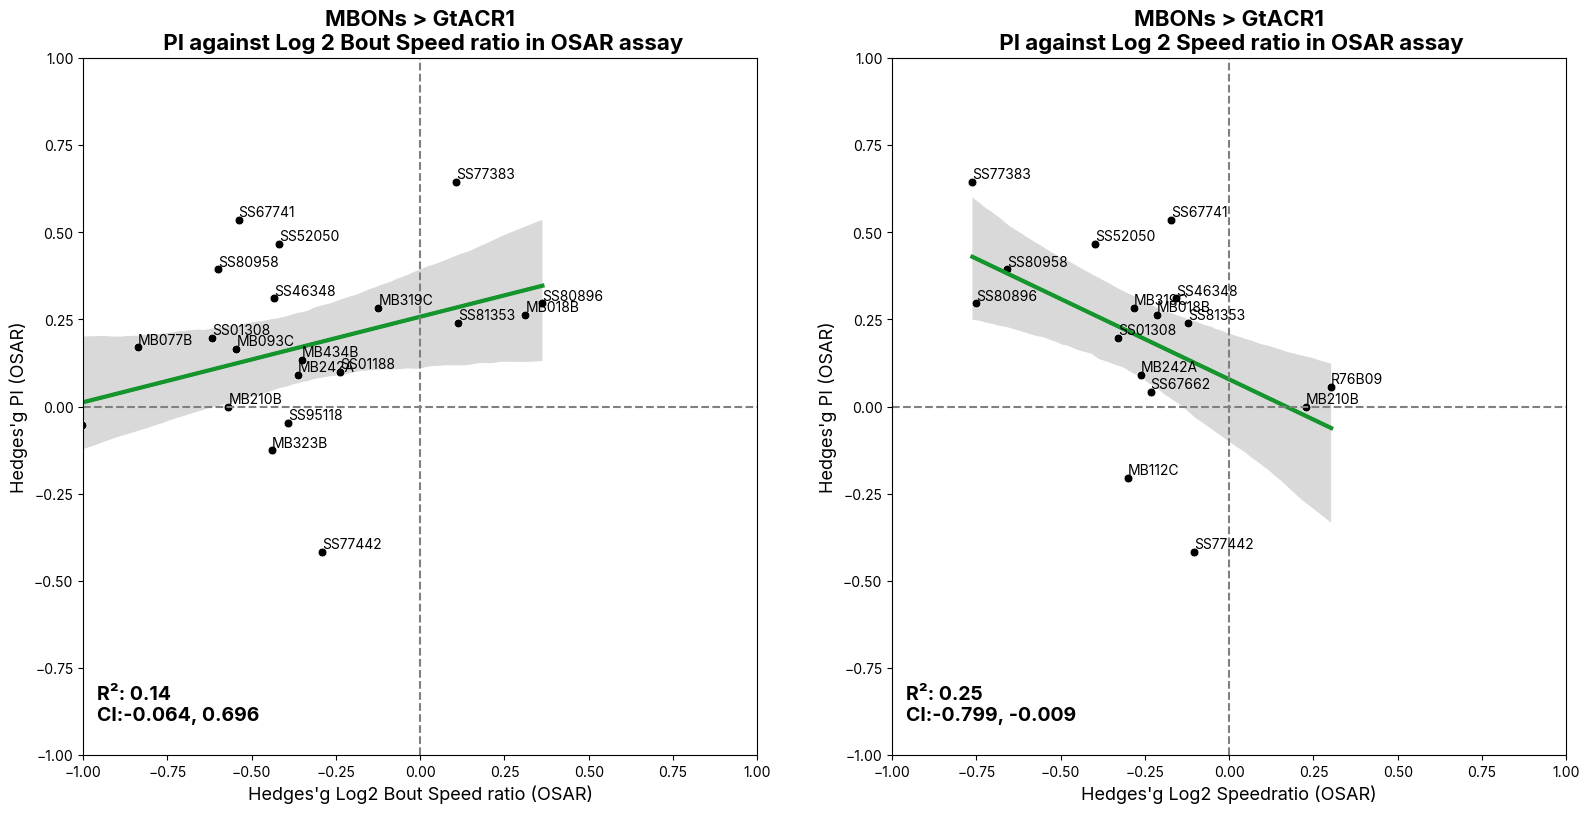

In [ ]:
#only for values above magnitude of 0.2 and no VT999036
import scipy.stats

plt.rcParams["font.family"] = "Inter"

conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")

    responder = "ACR"

    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
        colorline = "#ff0000"

    if responder == 'ACR':
        responderrename = "GtACR1"
        df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
        colorline = "#14962c"

    figosarplot, axscatter_o = plt.subplots(1, 2, figsize=(16, 8), gridspec_kw={"width_ratios":[1,1]})

    # First subplot
    y_label_1 = "PI_Δg_OSAR"
    x_label_1 = 'Log2 Bout Speed ratio_Δg_OSAR'

    df02omitteddf = df_specificmbon[~((df_specificmbon[x_label_1].abs() < 0.2) & (df_specificmbon[y_label_1].abs() < 0.2))].reset_index(drop=True)
    df02omitteddf = df02omitteddf[~df02omitteddf['MBON'].isin(['VT999036'])]

    sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[0]) #ci color
    sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[0])  #line color
    sns.scatterplot(x=x_label_1, y=y_label_1, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[0])

    axscatter_o[0].set_ylabel("Hedges'g PI (OSAR)", fontsize = 13)
    axscatter_o[0].set_xlabel("Hedges'g Log2 Bout Speed ratio (OSAR)", fontsize = 13)
    axscatter_o[0].grid(False)
    axscatter_o[0].set_ylim([-1, 1])
    axscatter_o[0].set_xlim([-1, 1])
    axscatter_o[0].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[0].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[0].set_title("MBONs > " + responderrename + "\n PI against Log 2 Bout Speed ratio in OSAR assay", weight = "bold", fontfamily = "Inter", fontsize = 16)
    axscatter_o[0].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df02omitteddf['MBON']):
        axscatter_o[0].annotate(k, (df02omitteddf.loc[n,x_label_1], df02omitteddf.loc[n,y_label_1]+0.01), fontsize = 10)

    #correlation for first subplot
    pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(df02omitteddf[x_label_1], df02omitteddf[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[0].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)


    # Second subplot
    y_label_2 = "PI_Δg_OSAR"
    x_label_2 = 'Log2 Speed ratio_Δg_OSAR'
    
    df_omitted02_2ndplot = df_specificmbon[~((df_specificmbon[x_label_2].abs() < 0.2) & (df_specificmbon[y_label_2].abs() < 0.2))].reset_index(drop=True)
    df_omitted02_2ndplot = df_omitted02_2ndplot[~df_omitted02_2ndplot['MBON'].isin(['VT999036'])]
    
    sns.regplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[1]) #ci color
    sns.regplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[1]) #linecolor
    sns.scatterplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, s = 40, color = 'k', ax=axscatter_o[1])

    axscatter_o[1].set_ylabel("Hedges'g PI (OSAR)", fontsize = 13)
    axscatter_o[1].set_xlabel("Hedges'g Log2 Speedratio (OSAR)", fontsize = 13)
    axscatter_o[1].grid(False)
    axscatter_o[1].set_ylim([-1, 1])
    axscatter_o[1].set_xlim([-1, 1])
    axscatter_o[1].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[1].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[1].set_title("MBONs > " + responderrename + "\n PI against Log 2 Speed ratio in OSAR assay", weight = "bold", fontsize = 16)
    axscatter_o[1].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df_omitted02_2ndplot['MBON']):
        axscatter_o[1].annotate(k, (df_omitted02_2ndplot.loc[n,x_label_2], df_omitted02_2ndplot.loc[n,y_label_2]+0.01), fontsize = 10)

    #correlation for second subplot
    pearsonscorrelation_cr2_2 = scipy.stats.pearsonr(df_omitted02_2ndplot[x_label_2], df_omitted02_2ndplot[y_label_2]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[1].annotate(f"R²: {(round(pearsonscorrelation_cr2_2[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_2,3)) + ", " + str(round(civalhigh_cr2_2,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)

    plt.tight_layout()
    plt.subplots_adjust(top = 0.95, wspace=0.2)

    plt.savefig(filesavedir + date + "_" + responder + "_linreg_ OSAR only.png", dpi = 1200, bbox_inches='tight')
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_in OSAR only.svg")

## Lin reg of falling and osar

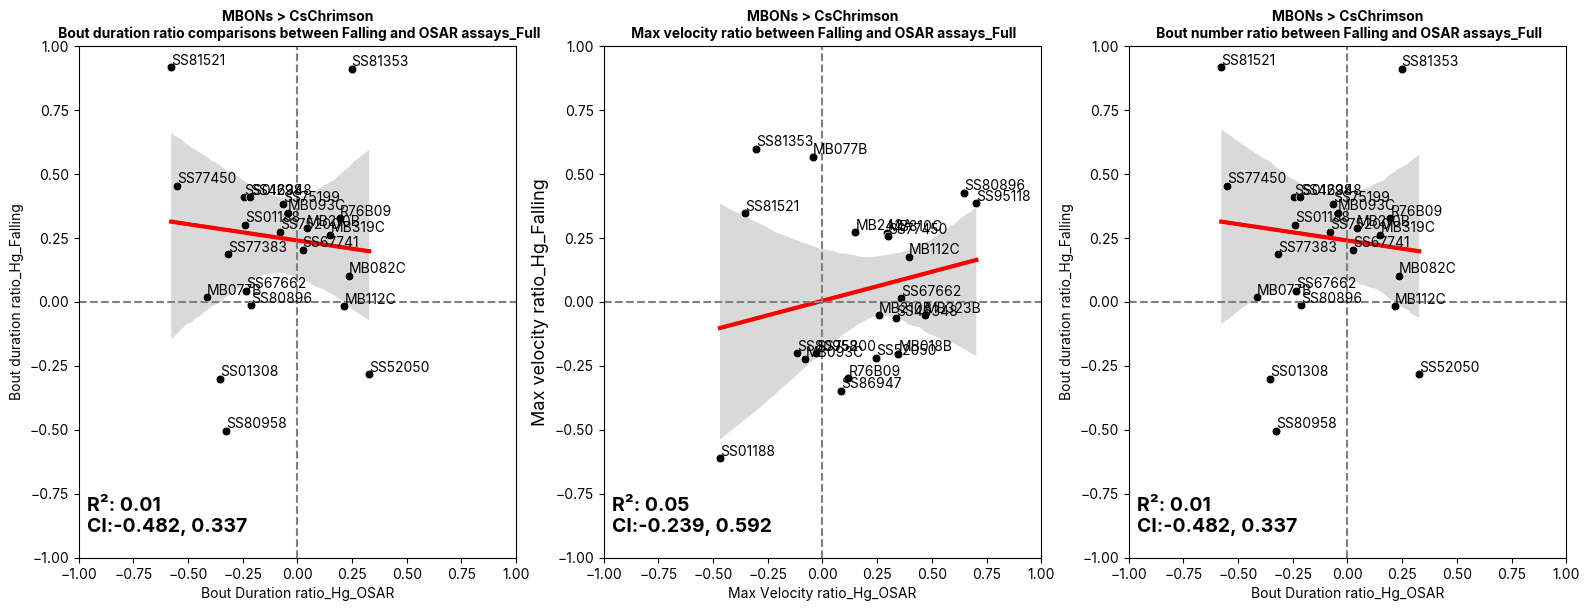

In [15]:
#only for values above magnitude of 0.2 and no VT999036
import scipy.stats

plt.rcParams["font.family"] = "Inter"

conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")

    responder = "Chrimson2"

    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
        colorline = "#ff0000"

    if responder == 'ACR':
        responderrename = "GtACR1"
        df_specificmbon = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
        colorline = "#14962c"

    figosarplot, axscatter_o = plt.subplots(1, 3, figsize=(16, 6), gridspec_kw={"width_ratios":[1,1,1]})

    # First subplot
    x_label_1 = "Bout Duration ratio_Hg_OSAR"
    y_label_1 = 'Bout duration ratio_Hg_Falling'

    df02omitteddf = df_specificmbon[~((df_specificmbon[x_label_1].abs() < 0.2) & (df_specificmbon[y_label_1].abs() < 0.2))].reset_index(drop=True)
    df02omitteddf = df02omitteddf[~df02omitteddf['MBON'].isin(['VT999036'])]

    sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[0]) #ci color
    sns.regplot(x=x_label_1, y=y_label_1, data=df02omitteddf, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[0])  #line color
    sns.scatterplot(x=x_label_1, y=y_label_1, data=df02omitteddf, s = 40, color = 'k', ax=axscatter_o[0])

    # axscatter_o[0].set_xlabel("Hedges'g Log2 BoutSpeedratio (OSAR)", fontsize = 13)
    # axscatter_o[0].set_ylabel("Hedges'g Log2 BoutSpeed ratio (Falling)", fontsize = 13)
    axscatter_o[0].grid(False)
    axscatter_o[0].set_ylim([-1, 1])
    axscatter_o[0].set_xlim([-1, 1])
    axscatter_o[0].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[0].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[0].set_title("MBONs > " + responderrename + "\n Bout duration ratio comparisons between Falling and OSAR assays_" + condition, weight = "bold", fontfamily = "Inter", fontsize = 10)
    axscatter_o[0].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df02omitteddf['MBON']):
        axscatter_o[0].annotate(k, (df02omitteddf.loc[n,x_label_1], df02omitteddf.loc[n,y_label_1]+0.01), fontsize = 10)

    #correlation for first subplot
    pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(df02omitteddf[x_label_1], df02omitteddf[y_label_1]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[0].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)


    # Second subplot
    x_label_2 = "Max Velocity ratio_Hg_OSAR"
    y_label_2 = 'Max velocity_Hg_Falling'
    
    df_omitted02_2ndplot = df_specificmbon[~((df_specificmbon[x_label_2].abs() < 0.2) & (df_specificmbon[y_label_2].abs() < 0.2))].reset_index(drop=True)
    df_omitted02_2ndplot = df_omitted02_2ndplot[~df_omitted02_2ndplot['MBON'].isin(['VT999036'])]
    
    sns.regplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[1]) #ci color
    sns.regplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[1]) #linecolor
    sns.scatterplot(x=x_label_2, y=y_label_2, data=df_omitted02_2ndplot, s = 40, color = 'k', ax=axscatter_o[1])

    # axscatter_o[1].set_xlabel("Hedges'g Log2 Speedratio (OSAR)", fontsize = 13)
    axscatter_o[1].set_ylabel("Max velocity ratio_Hg_Falling", fontsize = 13)
    axscatter_o[1].grid(False)
    axscatter_o[1].set_ylim([-1, 1])
    axscatter_o[1].set_xlim([-1, 1])
    axscatter_o[1].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[1].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[1].set_title("MBONs > " + responderrename + "\n Max velocity ratio between Falling and OSAR assays_" + condition, weight = "bold", fontsize = 10)
    axscatter_o[1].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df_omitted02_2ndplot['MBON']):
        axscatter_o[1].annotate(k, (df_omitted02_2ndplot.loc[n,x_label_2], df_omitted02_2ndplot.loc[n,y_label_2]+0.01), fontsize = 10)

    #correlation for second subplot
    pearsonscorrelation_cr2_2 = scipy.stats.pearsonr(df_omitted02_2ndplot[x_label_2], df_omitted02_2ndplot[y_label_2]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[1].annotate(f"R²: {(round(pearsonscorrelation_cr2_2[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_2,3)) + ", " + str(round(civalhigh_cr2_2,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)

    # third subplot
    x_label_3 = "Bout Duration ratio_Hg_OSAR"
    y_label_3 = 'Bout duration ratio_Hg_Falling'
    
    df_omitted02_3rdplot = df_specificmbon[~((df_specificmbon[x_label_3].abs() < 0.2) & (df_specificmbon[y_label_3].abs() < 0.2))].reset_index(drop=True)
    df_omitted02_3rdplot = df_omitted02_3rdplot[~df_omitted02_3rdplot['MBON'].isin(['VT999036'])]
    
    sns.regplot(x=x_label_3, y=y_label_3, data=df_omitted02_3rdplot, ci = 95, scatter = False, line_kws={"color": "black"}, ax=axscatter_o[2]) #ci color
    sns.regplot(x=x_label_3, y=y_label_3, data=df_omitted02_3rdplot, ci = 0, scatter = False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_o[2]) #linecolor
    sns.scatterplot(x=x_label_3, y=y_label_3, data=df_omitted02_3rdplot, s = 40, color = 'k', ax=axscatter_o[2])

    # axscatter_o[1].set_xlabel("Hedges'g Log2 Speedratio (OSAR)", fontsize = 13)
    #axscatter_o[2].set_ylabel("Max velocity ratio_Hg_Falling", fontsize = 23)
    axscatter_o[2].grid(False)
    axscatter_o[2].set_ylim([-1, 1])
    axscatter_o[2].set_xlim([-1, 1])
    axscatter_o[2].axvline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[2].axhline(0, c=(.5, .5, .5), ls= '--')
    axscatter_o[2].set_title("MBONs > " + responderrename + "\n Bout number ratio between Falling and OSAR assays_" + condition, weight = "bold", fontsize = 10)
    axscatter_o[2].yaxis.set_tick_params(labelbottom=True)

    for n, k in enumerate(df_omitted02_3rdplot['MBON']):
        axscatter_o[2].annotate(k, (df_omitted02_3rdplot.loc[n,x_label_3], df_omitted02_3rdplot.loc[n,y_label_3]+0.01), fontsize = 10)

    #correlation for second subplot
    pearsonscorrelation_cr2_2 = scipy.stats.pearsonr(df_omitted02_3rdplot[x_label_3], df_omitted02_3rdplot[y_label_3]) #correlation instead of linear regression: trying to find the relationship rather than causation    
    civallow_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[0] 
    civalhigh_cr2_2 = pearsonscorrelation_cr2_2.confidence_interval(confidence_level=0.95)[1]  
    axscatter_o[2].annotate(f"R²: {(round(pearsonscorrelation_cr2_2[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_2,3)) + ", " + str(round(civalhigh_cr2_2,3)), (0.02, 0.05), 
                            ha = "left", xycoords = 'axes fraction', weight = "bold", fontsize = 14)
    plt.tight_layout()
    plt.subplots_adjust(top = 0.95, wspace=0.2)

    # plt.savefig(filesavedir + date + "_" + responder + "_linreg_" + condition +".png", dpi = 1200, bbox_inches='tight')
    # plt.savefig(filesavedir + date + "_" + responder + "_linreg_" + condition + ".svg")

## Comparison of PI against all types

In [13]:
singlecellmbon = ['MB018B',
'MB080C',
'MB085C',
'MB091C',
'MB112C',
'MB242A',
'MB262B',
'MB298B',
'MB399B',
'MB622B',
'SS01127',
'SS01143',
'SS01188',
'SS01194',
'SS01308',
'SS01337',
'SS01388',
'SS46348',
'SS67662',
'SS67727',
'SS67728',
'SS67741',
'SS67755',
'SS75199',
'SS75200',
'SS76094',
'SS77383',
'SS77424',
'SS77450',
'SS80974',
'SS81353',
'SS81521',
'SS95118',
'SS97567']


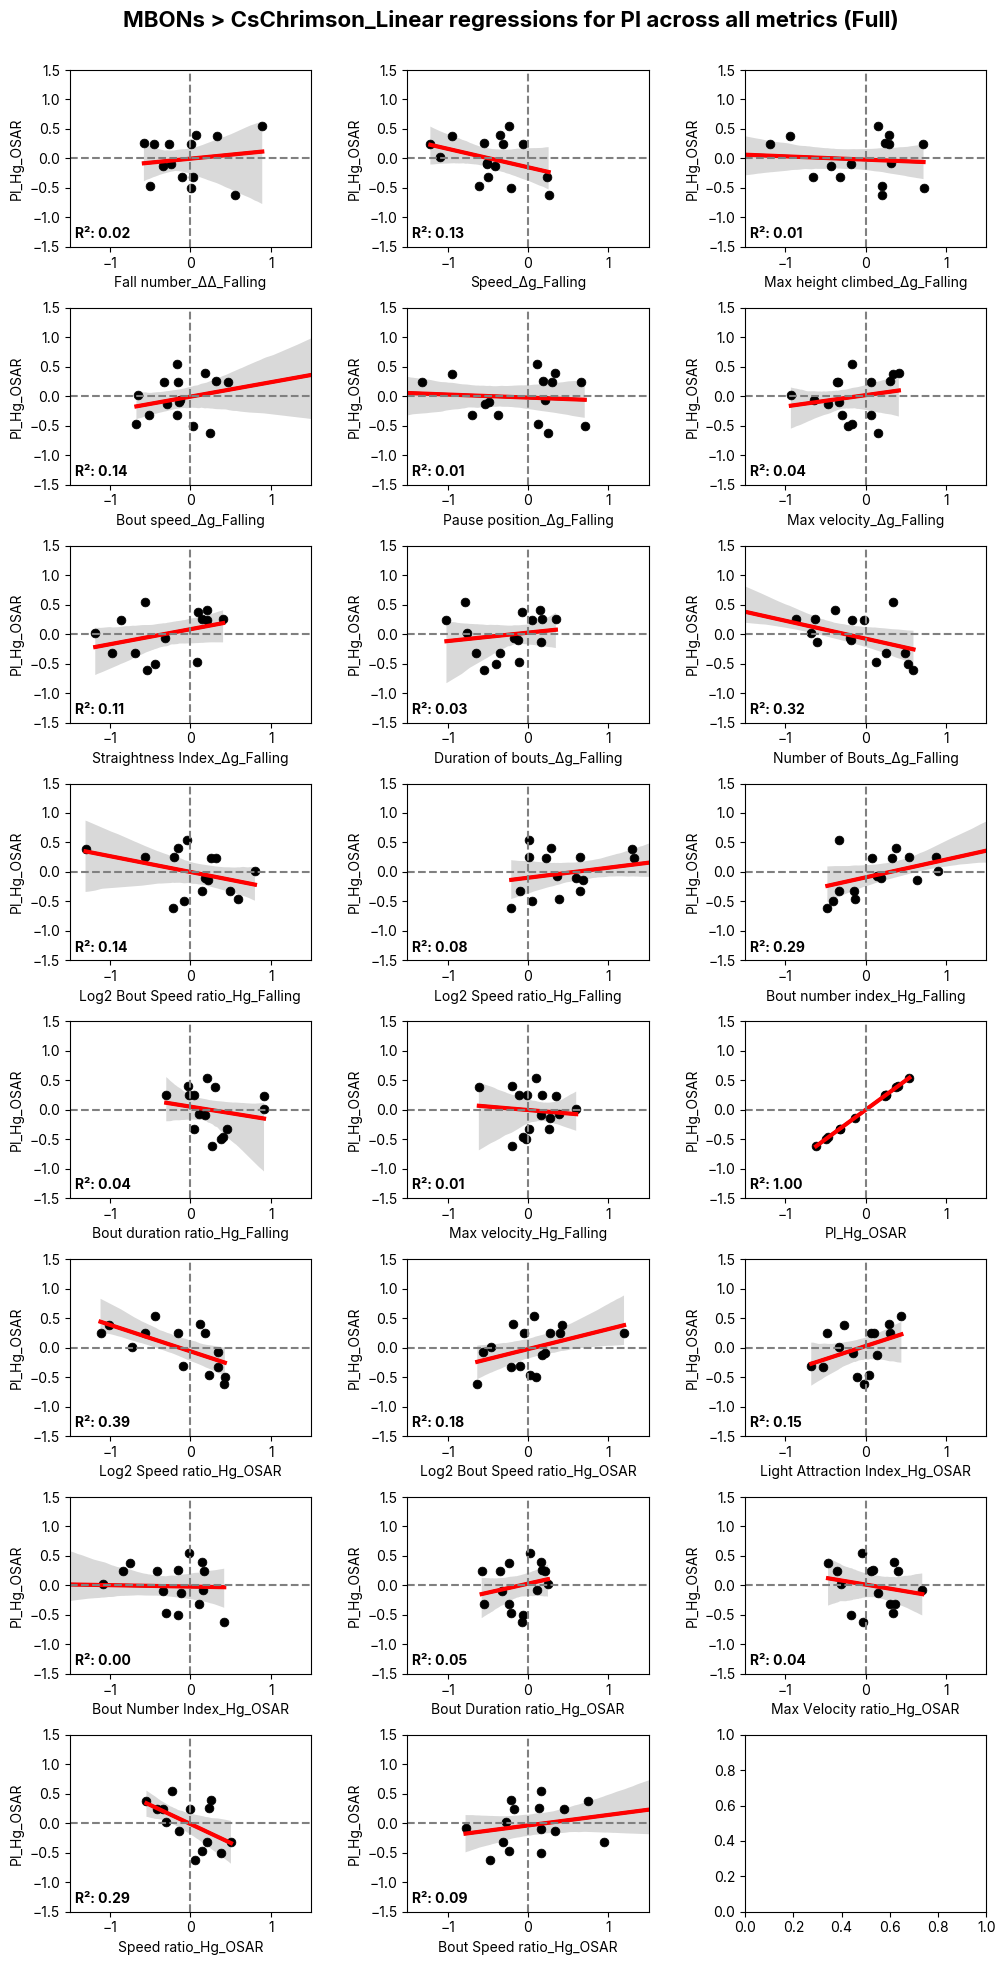

Generated plot for Full condition


In [14]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

# Define the three condition files
conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
        colorline = 'red'
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_linereg = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
        colorline = 'green'
    
    totalmapplots = df_linereg.drop(columns = ['genotypeandresponder', 'responder'])
    df_totalmetrics_origin = totalmapplots[totalmapplots['MBON'].isin(singlecellmbon)]
    
    df_totalmetrics = df_totalmetrics_origin.drop(columns = ['MBON'])
    metrictype = df_totalmetrics.columns.tolist()
        
    figlinregplots, axes = plt.subplots(8,3, figsize=(10,20))
    axscatter_linreg = axes.flatten()
       
    for k,j in zip(metrictype, range(len(metrictype))):
  
        x_label_1 = k 
        y_label_1 = 'PI_Hg_OSAR'    

        data_nt = df_totalmetrics_origin[~((df_totalmetrics_origin[x_label_1].abs() < 0.1) & (df_totalmetrics_origin[y_label_1].abs() < 0.2))].reset_index(drop=True)
        
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_linreg[j])
        sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_linreg[j])
        sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color= "black", edgecolors="face", ax=axscatter_linreg[j])

        axscatter_linreg[j].grid(False)
        axscatter_linreg[j].set_ylim([-1.5, 1.5])
        axscatter_linreg[j].set_xlim([-1.5, 1.5])
        axscatter_linreg[j].axvline(0, c=(.5, .5, .5), ls='--')
        axscatter_linreg[j].axhline(0, c=(.5, .5, .5), ls='--')
        
        axscatter_linreg[j].yaxis.set_tick_params(labelbottom=True)

        # Correlation for subplot
        pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
        # civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
        # civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
        # axscatter_linreg[j].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
        #                         (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
        axscatter_linreg[j].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}", 
                                (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=10)
    
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.4)
    
    figlinregplots.suptitle(f"MBONs > {responderrename}_Linear regressions for PI across all metrics ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    #plt.savefig(filesavedir + date + "_" + responder + "_linreg_allmetrics_" + condition + ".png", dpi=1200, bbox_inches='tight')
    #plt.savefig(filesavedir + date + "_" + responder + "_linreg_allmetrics_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")

## Neurotransmitter types

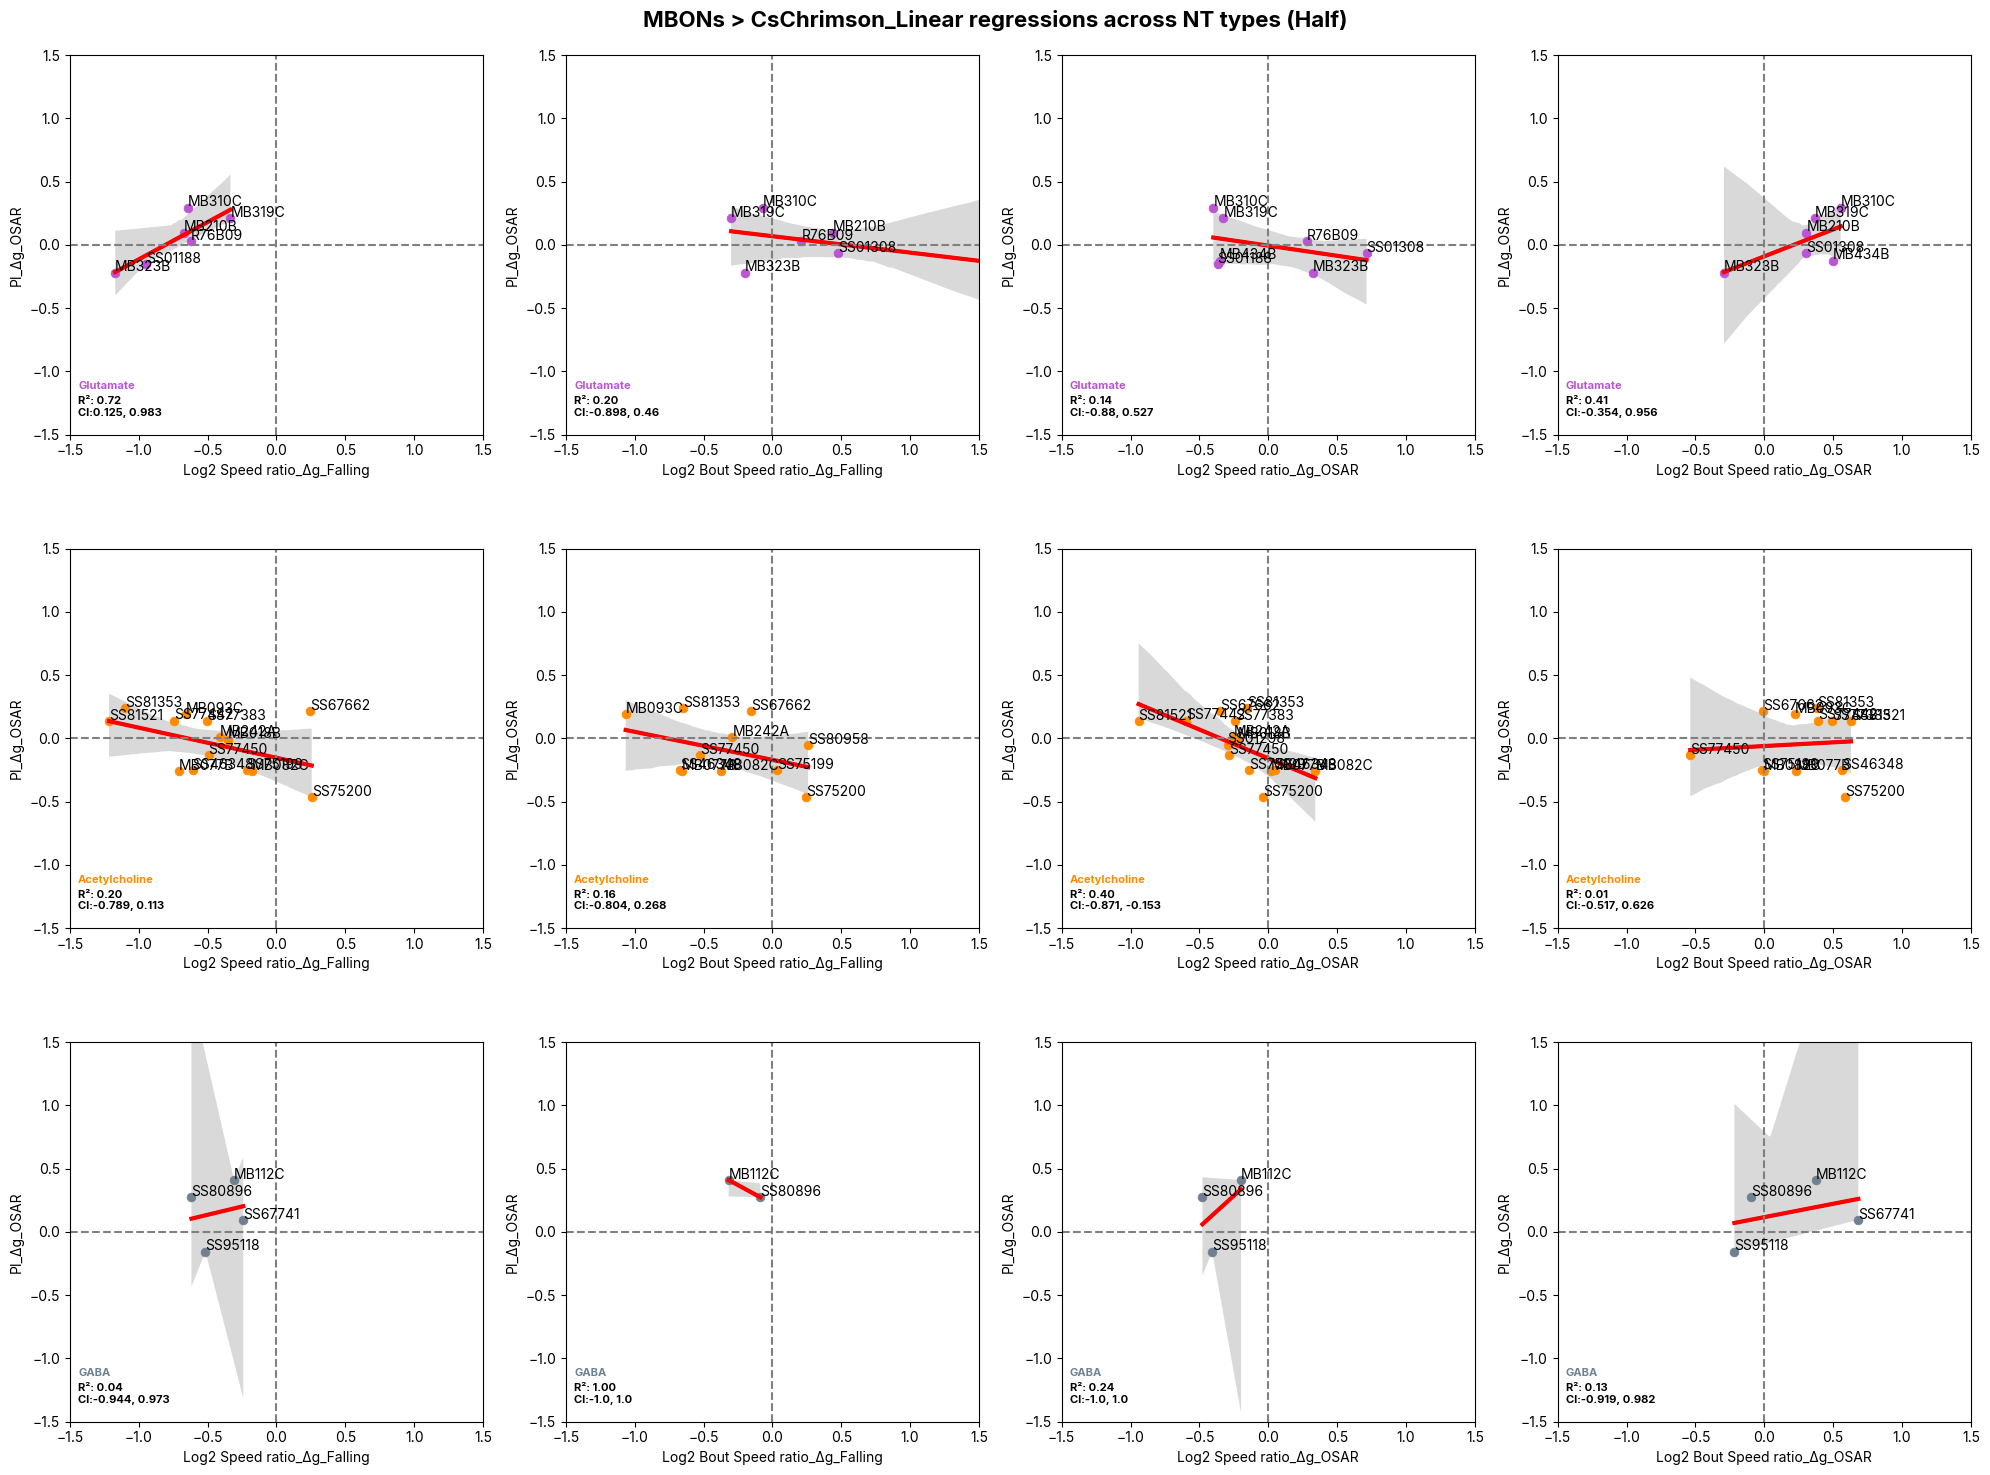

Generated plot for Half condition


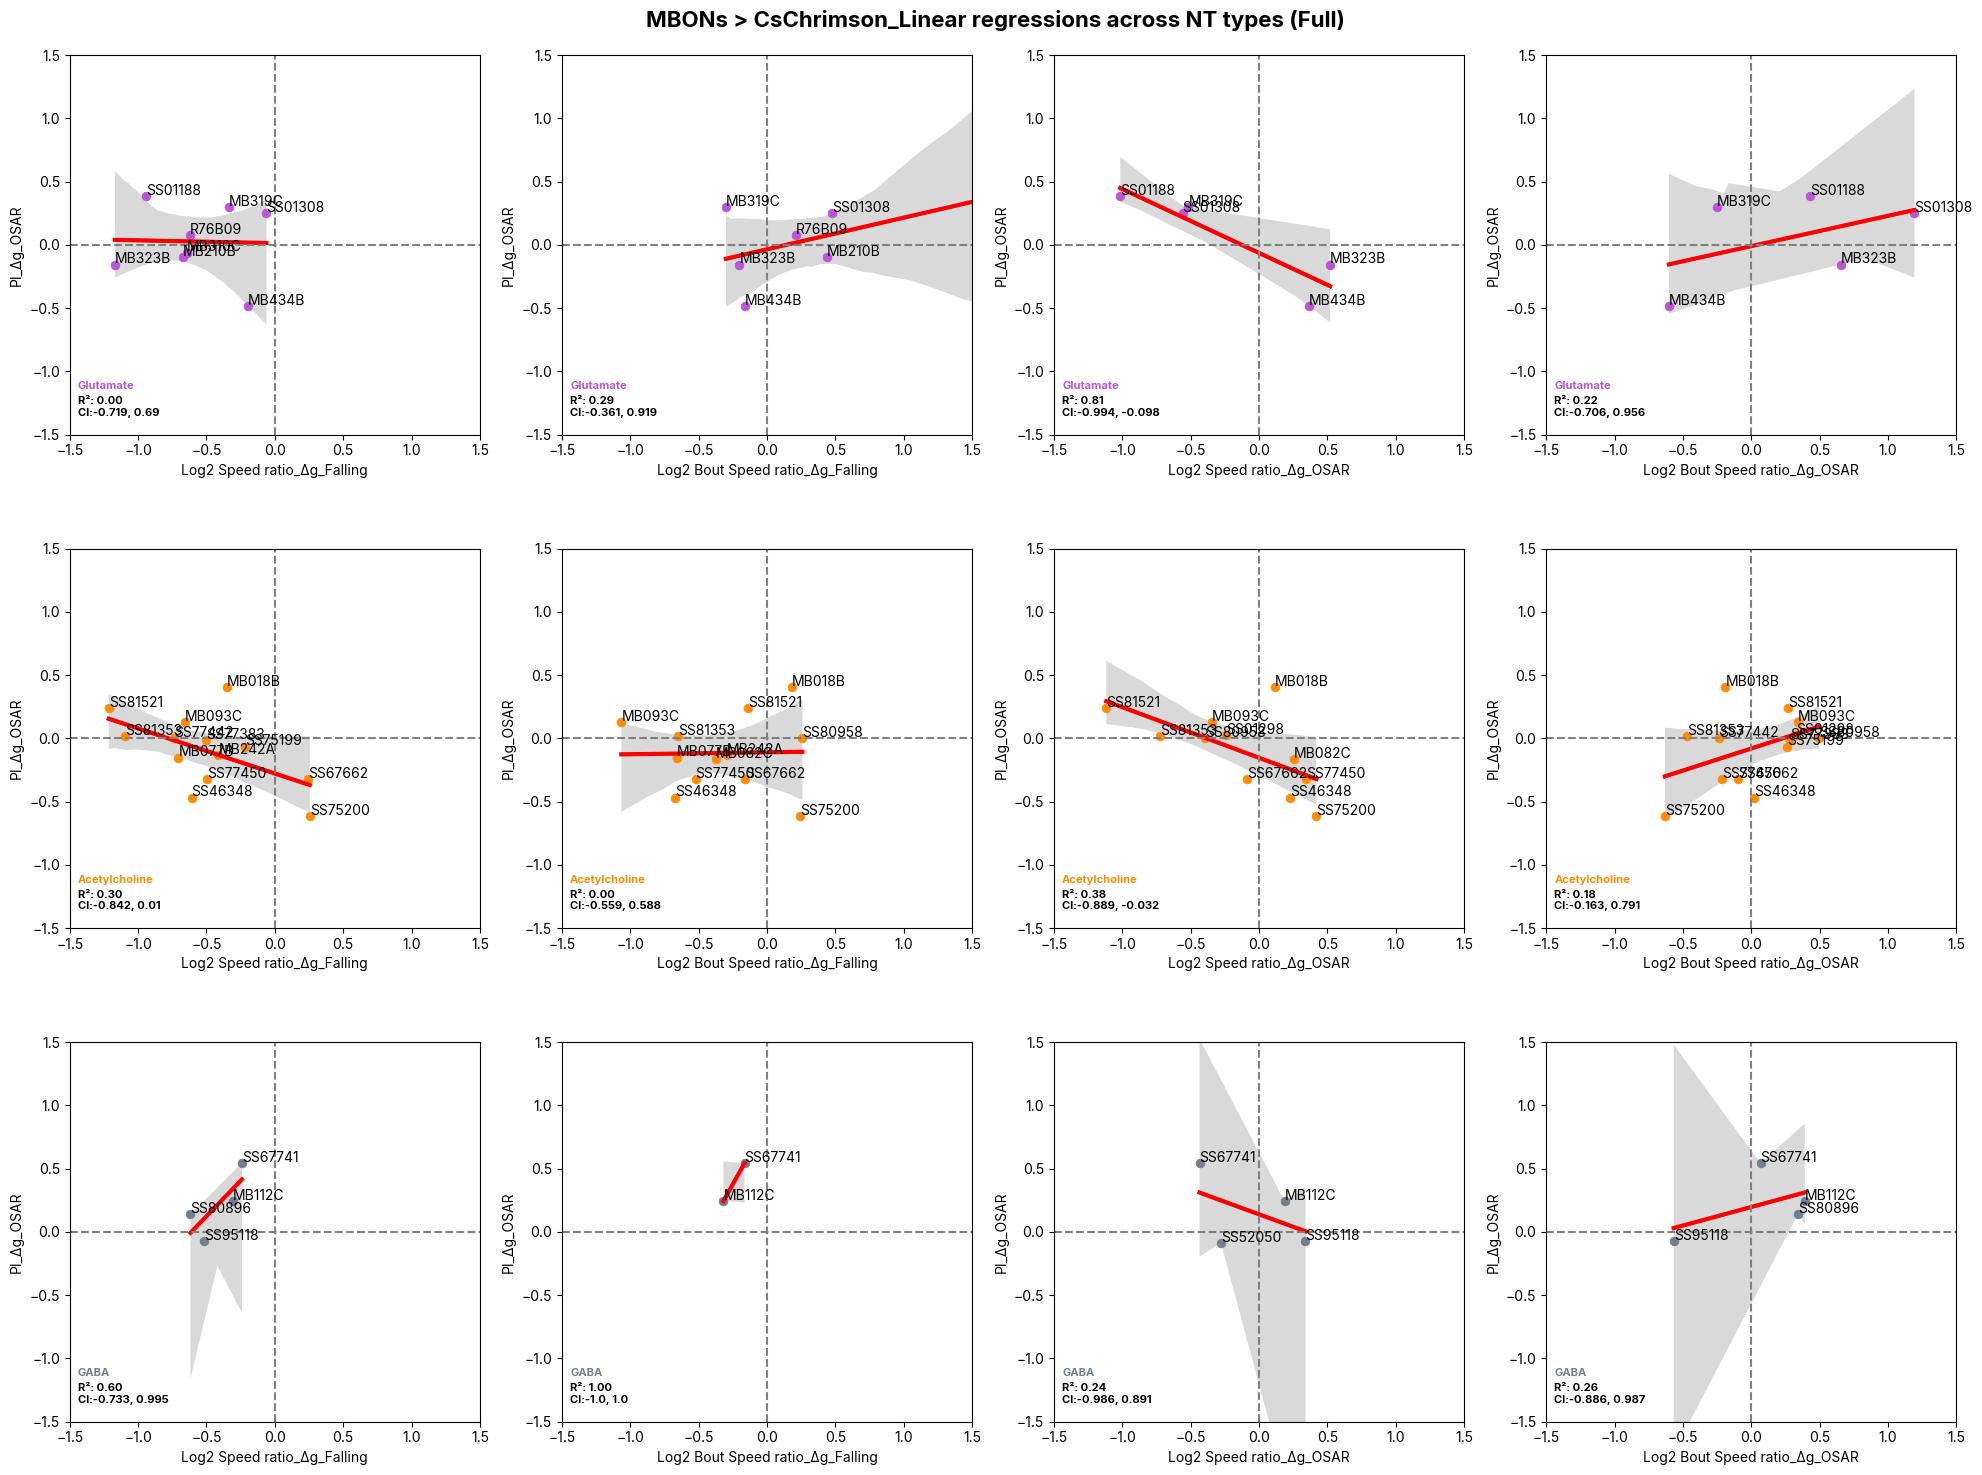

Generated plot for Full condition


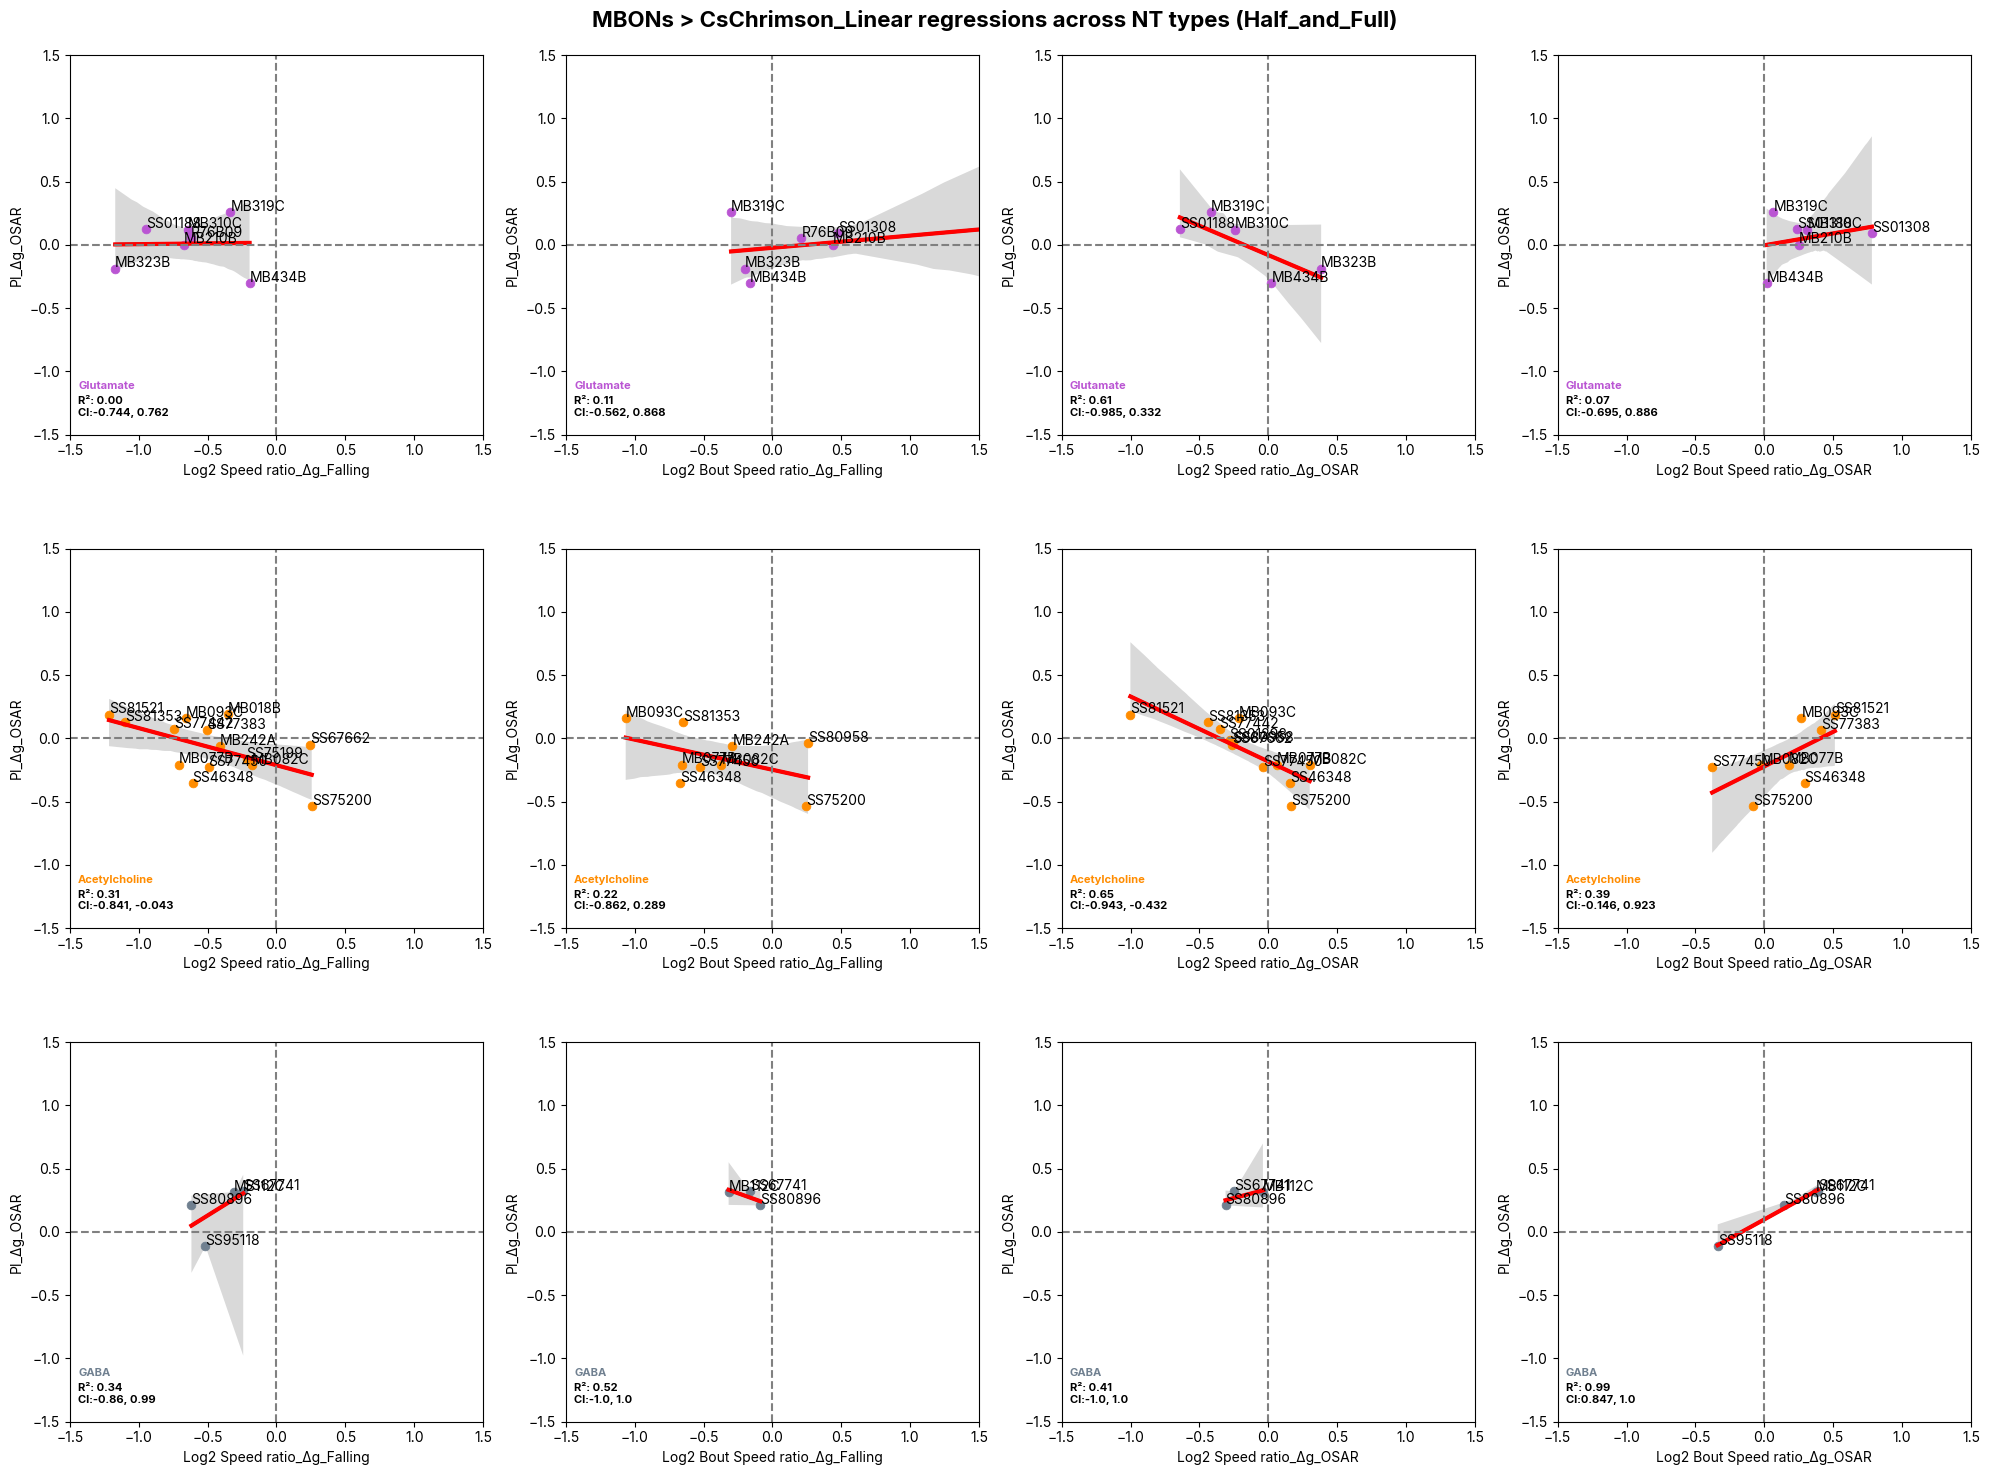

Generated plot for Half_and_Full condition


In [ ]:
import scipy.stats

plt.rcParams["font.family"] = "Inter"

responder = "Chrimson2"

# Define the three condition files
conditions = ['Full']

for condition in conditions:
    # Read the specific condition file
    totalmetriccomparison = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar falling\\Totalcomparisonofallmetrics-" + condition + ".xlsx")
    
    df_nt2 = totalmetriccomparison.drop(columns=['genotypeandresponder'])
    df_nt2 = df_nt2[~df_nt2['MBON'].isin(['VT999036'])]
    
    ntloblist = []
    mbonloclst = []
    df_nttotal = df_nt2.copy()
    for n in df_nt2['MBON']:    
        ntloblist.append(lobelocation[lobelocation['MBON'] == n]['Neurotransmitter'].values[0])
        mbonloclst.append(lobelocation[lobelocation['MBON'] == n]['MBON number'].values[0])
    df_nttotal['NT'] = ntloblist
    df_nttotal['Name'] = mbonloclst
    
    if responder == 'Chrimson2':
        responderrename = "CsChrimson"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="Chrimson2"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'red'
        nttypes_color = ['mediumorchid', "darkorange", "slategrey"]
    
    if responder == 'ACR':
        responderrename = "GtACR1"
        df_neurotrans = df_nttotal[df_nttotal['responder']=="ACR"].sort_values(by="PI_Δg_OSAR", ascending=True).reset_index(drop=True)
        colorline = 'green'
        nttypes_color = ['blue', "darkturquoise", "indigo"]
    
    
    figntplot, axes = plt.subplots(3,4, figsize=(20,15))
    axscatter_nt = axes.flatten()
    nttypes = ['Glutamate', "Acetylcholine", "GABA"]
    
    metrictype = ['Log2 Speed ratio_Δg_Falling', 'Log2 Bout Speed ratio_Δg_Falling', 'Log2 Speed ratio_Δg_OSAR', 'Log2 Bout Speed ratio_Δg_OSAR']
    plotcounter = 0
    
    for n,j in zip(nttypes, nttypes_color):
        unfiltered_dfnt = df_neurotrans[df_neurotrans['NT'] == n].reset_index(drop=True)
        
        for k in metrictype:
            x_label_1 = k
            y_label_1 = 'PI_Δg_OSAR'      

            data_nt = unfiltered_dfnt[~((unfiltered_dfnt[x_label_1].abs() < 0.2) & (unfiltered_dfnt[y_label_1].abs() < 0.2))].reset_index(drop=True)
            #data_nt = unfiltered_dfnt.copy()
          
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=95, scatter=False, line_kws={"color": "black"}, ax=axscatter_nt[plotcounter])
            sns.regplot(x=x_label_1, y=y_label_1, data=data_nt, ci=0, scatter=False, line_kws={"color": colorline, 'lw': 3}, ax=axscatter_nt[plotcounter])
            sns.scatterplot(x=x_label_1, y=y_label_1, data=data_nt, s=40, color=j, edgecolors="face", ax=axscatter_nt[plotcounter])
    
            axscatter_nt[plotcounter].grid(False)
            axscatter_nt[plotcounter].set_ylim([-1.5, 1.5])
            axscatter_nt[plotcounter].set_xlim([-1.5, 1.5])
            axscatter_nt[plotcounter].axvline(0, c=(.5, .5, .5), ls='--')
            axscatter_nt[plotcounter].axhline(0, c=(.5, .5, .5), ls='--')
           
            axscatter_nt[plotcounter].yaxis.set_tick_params(labelbottom=True)
    
            for m, p in enumerate(data_nt['MBON']):
                axscatter_nt[plotcounter].annotate(p, (data_nt.loc[m,x_label_1], data_nt.loc[m,y_label_1]+0.01), fontsize=10)
    
            # Correlation for subplot
            pearsonscorrelation_cr2_1 = scipy.stats.pearsonr(data_nt[x_label_1], data_nt[y_label_1])
            civallow_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[0] 
            civalhigh_cr2_1 = pearsonscorrelation_cr2_1.confidence_interval(confidence_level=0.95)[1]  
            axscatter_nt[plotcounter].annotate(f"R²: {(round(pearsonscorrelation_cr2_1[0],3))**2:.2f}" + "\nCI:" + str(round(civallow_cr2_1,3)) + ", " + str(round(civalhigh_cr2_1,3)), 
                                    (0.02, 0.05), ha="left", xycoords='axes fraction', weight="bold", fontsize=8)
            
            # Naming of nt type
            axscatter_nt[plotcounter].annotate(n, (0.02, 0.12), ha="left", xycoords='axes fraction', color=j, weight="bold", fontsize=8)
            plotcounter += 1
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, wspace=0.2, hspace=0.3)
    
    figntplot.suptitle(f"MBONs > {responderrename}_Linear regressions across NT types ({condition})", weight="bold", fontfamily="Inter", fontsize=16)
    
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".png", dpi=1200, bbox_inches='tight')
    plt.savefig(filesavedir + date + "_" + responder + "_linreg_nttypes_" + condition + ".svg")
    
    plt.show()
    
    print(f"Generated plot for {condition} condition")